# Universal Functions: Fast Element-Wise Array Functions

In [6]:
import numpy as np

A universal function, or ufunc, is a function that performs element-wise operations on data in ndarrays. You can think of them as fast vectorized wrappers for simple functions that take one or more scalar values and produce one or more scalar results.
Many ufuncs are simple element-wise transformations, like sqrt or exp

In [7]:
arr = np.arange(10)
arr
np.sqrt(arr)
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

In [8]:
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [9]:
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

These are referred to as unary ufuncs. Others, such as add or maximum, take two arrays (thus, binary ufuncs) and return a single array as the result

In [10]:
x = np.random.randn(8)
y = np.random.randn(8)
print(x)
print(y)
np.maximum(x, y)

[-0.46442085  0.1858397   0.35780549 -1.16738826 -0.50755786  1.3862432
  1.01069538 -0.99077048]
[ 0.29997149 -1.78301783 -0.6817478   0.28051799 -1.6584995  -0.91587352
 -1.18951825  0.34042231]


array([ 0.29997149,  0.1858397 ,  0.35780549,  0.28051799, -0.50755786,
        1.3862432 ,  1.01069538,  0.34042231])

Here, numpy.maximum computed the element-wise maximum of the elements in x and
y.
While not common, a ufunc can return multiple arrays. modf is one example, a vectorized version of the built-in Python divmod; it returns the fractional and integral parts of a floating-point array

In [11]:
arr = np.random.randn(7) * 5
arr

array([  0.34541344,   2.37445791, -10.03324653,   0.52479525,
         0.0665878 ,  -6.1289616 ,  -6.41952713])

In [12]:
arr

array([  0.34541344,   2.37445791, -10.03324653,   0.52479525,
         0.0665878 ,  -6.1289616 ,  -6.41952713])

In [13]:
remainder, whole_part = np.modf(arr)
print(remainder)
print(whole_part)

[ 0.34541344  0.37445791 -0.03324653  0.52479525  0.0665878  -0.1289616
 -0.41952713]
[  0.   2. -10.   0.   0.  -6.  -6.]


In [14]:
arr

array([  0.34541344,   2.37445791, -10.03324653,   0.52479525,
         0.0665878 ,  -6.1289616 ,  -6.41952713])

Ufuncs accept an optional out argument that allows them to operate in-place on arrays

In [18]:
arr
np.sqrt(arr)
np.sqrt(arr, arr)
arr

/var/folders/s2/qgwt9vb906s_xvpbk7f_49g00000gn/T/ipykernel_1691/2118003981.py:2: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr)
/var/folders/s2/qgwt9vb906s_xvpbk7f_49g00000gn/T/ipykernel_1691/2118003981.py:3: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr, arr)


array([2.61460301,        nan, 1.09871088, 1.55501365, 1.83590784,
              nan, 1.31659027])

### Expressing Conditional Logic as Array Operations

The numpy.where function is a vectorized version of the ternary expression x if condition else y. Suppose we had a boolean array and two arrays of values

In [16]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

Suppose we wanted to take a value from xarr whenever the corresponding value in cond is True, and otherwise take the value from yarr. A list comprehension doing this might look like

In [17]:
result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]
result

[1.1, 2.2, 1.3, 1.4, 2.5]

This has multiple problems. First, it will not be very fast for large arrays (because all the work is being done in interpreted Python code). Second, it will not work with multidimensional arrays. With np.where you can write this very concisely

In [18]:
result = np.where(cond, xarr, yarr)
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

The second and third arguments to np.where don’t need to be arrays; one or both of them can be scalars. A typical use of where in data analysis is to produce a new array of values based on another array. Suppose you had a matrix of randomly generated data and you wanted to replace all positive values with 2 and all negative values with –2. This is very easy to do with np.where

In [19]:
arr = np.random.randn(4, 4)
arr

array([[ 1.22256234, -0.04313893,  0.43240037, -0.31052075],
       [ 0.26841367,  0.15051928,  1.14072619,  0.76272959],
       [ 0.98127992,  1.43961835,  2.28677553, -2.2583096 ],
       [ 0.82921721,  0.7814575 , -0.49980806, -0.74021455]])

In [20]:
arr > 0

array([[ True, False,  True, False],
       [ True,  True,  True,  True],
       [ True,  True,  True, False],
       [ True,  True, False, False]])

In [21]:
np.where(arr > 0, 2, -2)

array([[ 2, -2,  2, -2],
       [ 2,  2,  2,  2],
       [ 2,  2,  2, -2],
       [ 2,  2, -2, -2]])

You can combine scalars and arrays when using np.where. For example, I can replace all positive values in arr with the constant 2 like so

In [22]:
np.where(arr > 0, 2, arr) # set only positive values to 2

array([[ 2.        , -0.04313893,  2.        , -0.31052075],
       [ 2.        ,  2.        ,  2.        ,  2.        ],
       [ 2.        ,  2.        ,  2.        , -2.2583096 ],
       [ 2.        ,  2.        , -0.49980806, -0.74021455]])

### Mathematical and Statistical Methods

A set of mathematical functions that compute statistics about an entire array or about the data along an axis are accessible as methods of the array class. You can use aggre‐ gations (often called reductions) like sum, mean, and std (standard deviation) either by calling the array instance method or using the top-level NumPy function.
Here I generate some normally distributed random data and compute some aggregate statistics

In [23]:
arr = np.random.randn(5, 4)
arr
arr.mean()
np.mean(arr)

0.008551577183261161

In [24]:
np.mean(arr)

0.008551577183261161

In [25]:
arr.sum()

0.17103154366522322

In [26]:
arr

array([[ 0.41273945,  0.05976063, -1.28171366,  2.27010619],
       [-0.42162271,  0.63257102,  0.14383593,  0.88654551],
       [ 2.02639369, -1.0511032 , -0.64756026, -0.09948172],
       [-0.59972019, -0.67631488,  0.87767775, -0.64814262],
       [-0.53308072, -0.91443099,  0.36142569, -0.62685337]])

Functions like mean and sum take an optional axis argument that computes the statistic over the given axis, resulting in an array with one fewer dimension

In [27]:
arr

array([[ 0.41273945,  0.05976063, -1.28171366,  2.27010619],
       [-0.42162271,  0.63257102,  0.14383593,  0.88654551],
       [ 2.02639369, -1.0511032 , -0.64756026, -0.09948172],
       [-0.59972019, -0.67631488,  0.87767775, -0.64814262],
       [-0.53308072, -0.91443099,  0.36142569, -0.62685337]])

In [28]:
arr.mean(axis=1)

array([ 0.36522315,  0.31033244,  0.05706213, -0.26162498, -0.42823485])

In [29]:
arr.sum(axis=0)

array([ 0.88470951, -1.94951742, -0.54633454,  1.78217399])

In [30]:
arr.sum(axis=0)

array([ 0.88470951, -1.94951742, -0.54633454,  1.78217399])

Here, arr.mean(1) means “compute mean across the columns” where arr.sum(0) means “compute sum down the rows.”
Other methods like cumsum and cumprod do not aggregate, instead producing an array of the intermediate results

In [31]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])
arr.cumsum()

array([ 0,  1,  3,  6, 10, 15, 21, 28])

In multidimensional arrays, accumulation functions like cumsum return an array of the same size, but with the partial aggregates computed along the indicated axis according to each lower dimensional slice

In [33]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
print(arr)
arr.cumsum(axis=1)
#arr.cumprod(axis=1)

[[0 1 2]
 [3 4 5]
 [6 7 8]]


array([[ 0,  1,  3],
       [ 3,  7, 12],
       [ 6, 13, 21]])

In [36]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
print(arr)
arr.mean()

[[0 1 2]
 [3 4 5]
 [6 7 8]]


4.0

In [37]:
arr.sum(axis=0) #stulpeliais sudeda

array([ 9, 12, 15])

In [38]:
arr.sum(axis=1) # eilutes sudeda

array([ 3, 12, 21])

### Methods for Boolean Arrays

Boolean values are coerced to 1 (True) and 0 (False) in the preceding methods. Thus, sum is often used as a means of counting True values in a boolean array

In [41]:
arr = np.random.randn(100)
(arr > 0).sum() # ATTENTION. THIS CALCULATES THE TRUTH VALUES BUT NOT THE POSITIVE NUMBER SUM.

50

In [40]:
arr

array([-0.70737666, -0.32057291,  0.2201588 ,  0.25188424, -0.69294449,
       -0.48309457,  0.48236928, -1.70984493,  0.07766736,  0.72162091,
       -0.96622265,  1.04021441,  1.46863119,  1.24345109,  1.24243819,
       -0.98105432,  0.35972056,  0.26522127, -0.53359568, -0.99163981,
       -0.42541994,  1.89491839, -0.78992252, -1.29053286, -1.66350823,
       -0.12034862, -1.80664167,  0.75331446,  0.86497532, -2.42315777,
        0.25317114,  0.35730266,  0.99459587, -1.72996321,  0.38971325,
       -0.00918296,  0.11917175, -2.84483092,  1.26663599,  0.53635354,
       -0.20084917, -0.67670331,  0.12131404, -1.32356334, -0.64598331,
        1.80203112,  0.04471461, -0.28589976, -1.57262811, -0.55583221,
        0.25206499, -0.15653832, -1.04451028,  1.48550859, -1.7753854 ,
       -0.11766995,  1.7983334 , -0.77704444,  0.20041211, -0.7111142 ,
       -0.59402109,  1.75725792,  1.30734582, -0.62904043,  0.06014959,
        0.12638608,  1.04302906,  0.96180219, -0.58569214, -1.59

There are two additional methods, any and all, useful especially for boolean arrays. any tests whether one or more values in an array is True, while all checks if every value is True

In [51]:
bools = np.array([False, False, True, False])
bools.any()
#bools.all()

True

These methods also work with non-boolean arrays, where non-zero elements evaluate to True

### Sorting

Like Python’s built-in list type, NumPy arrays can be sorted in-place with the sort method

![f](figures/figuresWes/numpy3.png)

In [149]:
np.random.seed(2)
arr = np.random.randn(4,3)
arr

array([[-0.41675785, -0.05626683, -2.1361961 ],
       [ 1.64027081, -1.79343559, -0.84174737],
       [ 0.50288142, -1.24528809, -1.05795222],
       [-0.90900761,  0.55145404,  2.29220801]])

!!!! ATTENTION. THE SORTING FUNCTIONS PUTS VALUE IN_PLACE. SO DO NOT OVER_SORT. axis = 0 and axis = 1 works.

In [53]:
arr.sort()
arr

array([[-0.68382802, -0.63485701,  0.90062723],
       [-0.06946567,  0.85294789,  0.96771776],
       [-1.61850763,  0.24268437,  0.37497891],
       [-0.30520759,  0.11094811,  1.20643182],
       [ 0.30714683,  1.1375802 ,  1.7297877 ],
       [-1.22788377,  0.54822759,  3.13310564]])

You can sort each one-dimensional section of values in a multidimensional array in- place along an axis by passing the axis number to sort

In [190]:
np.random.seed(1)
arr = np.random.randn(4, 3)
arr

array([[ 1.62434536, -0.61175641, -0.52817175],
       [-1.07296862,  0.86540763, -2.3015387 ],
       [ 1.74481176, -0.7612069 ,  0.3190391 ],
       [-0.24937038,  1.46210794, -2.06014071]])

In [191]:
arr.sort(axis=1)
arr

array([[-0.61175641, -0.52817175,  1.62434536],
       [-2.3015387 , -1.07296862,  0.86540763],
       [-0.7612069 ,  0.3190391 ,  1.74481176],
       [-2.06014071, -0.24937038,  1.46210794]])

In [187]:
arr.sort(axis=0)
arr

array([[-1.07296862, -0.7612069 , -2.3015387 ],
       [-0.24937038, -0.61175641, -2.06014071],
       [ 1.62434536,  0.86540763, -0.52817175],
       [ 1.74481176,  1.46210794,  0.3190391 ]])

The top-level method np.sort returns a sorted copy of an array instead of modifying the array in-place. A quick-and-dirty way to compute the quantiles of an array is to sort it and select the value at a particular rank

In [72]:
np.random.seed(10)
large_arr = np.random.randn(1000)

In [73]:
large_arr

array([ 1.3315865 ,  0.71527897, -1.54540029, -0.00838385,  0.62133597,
       -0.72008556,  0.26551159,  0.10854853,  0.00429143, -0.17460021,
        0.43302619,  1.20303737, -0.96506567,  1.02827408,  0.22863013,
        0.44513761, -1.13660221,  0.13513688,  1.484537  , -1.07980489,
       -1.97772828, -1.7433723 ,  0.26607016,  2.38496733,  1.12369125,
        1.67262221,  0.09914922,  1.39799638, -0.27124799,  0.61320418,
       -0.26731719, -0.54930901,  0.1327083 , -0.47614201,  1.30847308,
        0.19501328,  0.40020999, -0.33763234,  1.25647226, -0.7319695 ,
        0.66023155, -0.35087189, -0.93943336, -0.48933722, -0.80459114,
       -0.21269764, -0.33914025,  0.31216994,  0.56515267, -0.14742026,
       -0.02590534,  0.2890942 , -0.53987907,  0.70816002,  0.84222474,
        0.2035808 ,  2.39470366,  0.91745894, -0.11227247, -0.36218045,
       -0.23218226, -0.5017289 ,  1.12878515, -0.69781003, -0.08112218,
       -0.52929608,  1.04618286, -1.41855603, -0.36249918, -0.12

In [75]:
large_arr[50]

-0.02590533681618617

In [76]:
large_arr[int(0.05 * len(large_arr))] # 5% quantile

-0.02590533681618617

In [82]:
large_arr.sort()
large_arr

array([-3.20440134, -2.97959677, -2.81600122, -2.81506131, -2.5114691 ,
       -2.43420867, -2.39557201, -2.29510333, -2.21075441, -2.17660863,
       -2.13171211, -2.09779187, -2.01771865, -2.00797519, -1.99439377,
       -1.98710415, -1.9836365 , -1.97772828, -1.96251852, -1.95451212,
       -1.94129968, -1.9219949 , -1.91688659, -1.90745689, -1.90101374,
       -1.89459389, -1.8916454 , -1.88485017, -1.85735817, -1.85618548,
       -1.766165  , -1.74673584, -1.7433723 , -1.73232142, -1.7110712 ,
       -1.69840149, -1.69196793, -1.6840774 , -1.68044592, -1.66863267,
       -1.65860471, -1.63558662, -1.63494414, -1.62644682, -1.61857075,
       -1.60885036, -1.58838082, -1.58655176, -1.56744801, -1.55754247,
       -1.54730539, -1.54540029, -1.53639521, -1.53306872, -1.52503429,
       -1.51779623, -1.51507568, -1.50832149, -1.50502675, -1.46141364,
       -1.45884438, -1.45878942, -1.44229888, -1.4405723 , -1.43111847,
       -1.42088052, -1.41855603, -1.41575321, -1.39065058, -1.38

### Unique and Other Set Logic

NumPy has some basic set operations for one-dimensional ndarrays. A commonly used one is np.unique, which returns the sorted unique values in an array

In [83]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
np.unique(names)

array(['Bob', 'Joe', 'Will'], dtype='<U4')

In [84]:
ints = np.array([3, 3, 3, 2, 2, 1, 1, 4, 4])
np.unique(ints)

array([1, 2, 3, 4])

Contrast np.unique with the pure Python alternative

In [85]:
sorted(set(names))

['Bob', 'Joe', 'Will']

Another function, np.in1d, tests membership of the values in one array in another, returning a boolean array

In [46]:
values = np.array([6, 0, 0, 3, 2, 5, 6])
np.in1d(values, [2, 3, 6])

array([ True, False, False,  True,  True, False,  True])

## File Input and Output with Arrays

NumPy is able to save and load data to and from disk either in text or binary format. In this section I only discuss NumPy’s built-in binary format, since most users will prefer pandas and other tools for loading text or tabular data (see Chapter 6 for much more).
np.save and np.load are the two workhorse functions for efficiently saving and load‐ ing array data on disk. Arrays are saved by default in an uncompressed raw binary format with file extension .npy

In [47]:
arr = np.arange(10)
np.save('some_array', arr)

If the file path does not already end in .npy, the extension will be appended. The array on disk can then be loaded with np.load

In [48]:
np.load('some_array.npy')

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

You save multiple arrays in an uncompressed archive using np.savez and passing the arrays as keyword arguments

In [ ]:
np.savez('array_archive.npz', a=arr, b=arr)

When loading an .npz file, you get back a dict-like object that loads the individual
arrays lazily

In [ ]:
arch = np.load('array_archive.npz')
arch['b']

If your data compresses well, you may wish to use numpy.savez_compressed instead

In [ ]:
np.savez_compressed('arrays_compressed.npz', a=arr, b=arr)

In [49]:
!rm some_array.npy
!rm array_archive.npz
!rm arrays_compressed.npz

rm: array_archive.npz: No such file or directory
rm: arrays_compressed.npz: No such file or directory


## Linear Algebra

Linear algebra, like matrix multiplication, decompositions, determinants, and other square matrix math, is an important part of any array library. Unlike some languages like MATLAB, multiplying two two-dimensional arrays with * is an element-wise product instead of a matrix dot product. Thus, there is a function dot, both an array method and a function in the numpy namespace, for matrix multiplication

In [88]:
x = np.array([[1., 2., 3.], [4., 5., 6.]])
y = np.array([[6., 23.], [-1, 7], [8, 9]])
print("x matrix", x)
print("y matrix", y)
x.dot(y)

x matrix [[1. 2. 3.]
 [4. 5. 6.]]
y matrix [[ 6. 23.]
 [-1.  7.]
 [ 8.  9.]]


array([[ 28.,  64.],
       [ 67., 181.]])

x.dot(y) is equivalent to np.dot(x, y):

In [89]:
np.dot(x, y)

array([[ 28.,  64.],
       [ 67., 181.]])

A matrix product between a two-dimensional array and a suitably sized one-
dimensional array results in a one-dimensional array

In [42]:
print(x)
print(np.ones(3))
np.dot(x, np.ones(3))

[[1. 2. 3.]
 [4. 5. 6.]]
[1. 1. 1.]


array([ 6., 15.])

The @ symbol (as of Python 3.5) also works as an infix operator that performs matrix multiplication

In [93]:
np.ones((3,3))

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [90]:
x @ np.ones(3)

array([ 6., 15.])

numpy.linalg has a standard set of matrix decompositions and things like inverse and determinant. These are implemented under the hood via the same industry- standard linear algebra libraries used in other languages like MATLAB and R, such as BLAS, LAPACK, or possibly (depending on your NumPy build) the proprietary Intel MKL (Math Kernel Library)

In [94]:
from numpy.linalg import inv, qr
X = np.random.randn(3, 3)
mat = X.T.dot(X)
inv(mat)
mat.dot(inv(mat))
q, r = qr(mat)
r

array([[-5.18383931, -0.75537463, -0.42128109],
       [ 0.        , -1.88017893, -1.06216655],
       [ 0.        ,  0.        ,  0.00583482]])

The expression X.T.dot(X) computes the dot product of X with its transpose X.T.

## Pseudorandom Number Generation

The numpy.random module supplements the built-in Python random with functions for efficiently generating whole arrays of sample values from many kinds of probability distributions. For example, you can get a 4 × 4 array of samples from the standard normal distribution using normal

In [95]:
samples = np.random.normal(size=(4, 4))
samples

array([[ 0.2519878 ,  1.74445999, -0.95810017,  1.82466896],
       [-1.67994538, -1.11440892,  0.05915103, -0.31570128],
       [ 0.47043213,  0.7763924 , -1.0646236 , -0.18260894],
       [ 0.21144786, -1.33272526, -0.20756993, -0.00782922]])

Python’s built-in random module, by contrast, only samples one value at a time. As you can see from this benchmark, numpy.random is well over an order of magnitude faster for generating very large samples

In [45]:
from random import normalvariate
N = 1000000
%timeit samples = [normalvariate(0, 1) for _ in range(N)]
%timeit np.random.normal(size=N)

540 ms ± 6.47 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
21.1 ms ± 143 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


We say that these are pseudorandom numbers because they are generated by an algorithm with deterministic behavior based on the seed of the random number generator. You can change NumPy’s random number generation seed using np.random.seed

In [46]:
np.random.seed(1234)

The data generation functions in numpy.random use a global random seed. To avoid global state, you can use numpy.random.RandomState to create a random number generator isolated from others

In [47]:
rng = np.random.RandomState(1234)
rng.randn(10)

array([ 0.47143516, -1.19097569,  1.43270697, -0.3126519 , -0.72058873,
        0.88716294,  0.85958841, -0.6365235 ,  0.01569637, -2.24268495])

#### STOP

## Example: Random Walks

In [127]:
import random
position = 0
walk = [position]
steps = 1000
for i in range(steps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

In [133]:
position

18

In [126]:
random.randint(0, 1)

0

In [97]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

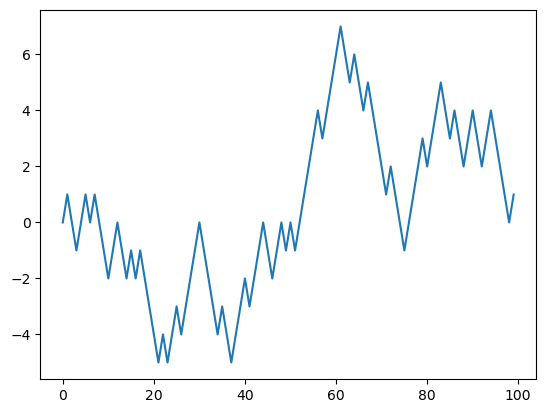

In [134]:
plt.plot(walk[:100])

In [57]:
np.random.seed(12345)

In [137]:
nsteps = 1000
draws = np.random.randint(0, 2, size=nsteps)
steps = np.where(draws > 0, 1, -1)
walk = steps.cumsum()

In [141]:
walk.max()

17

In [138]:
walk.min()
walk.max()

17

In [51]:
(np.abs(walk) >= 10).argmax()

55

### Simulating Many Random Walks at Once

In [ ]:
nwalks = 5000
nsteps = 1000
draws = np.random.randint(0, 2, size=(nwalks, nsteps)) # 0 or 1
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(1)
walks

In [ ]:
walks.max()
walks.min()

In [ ]:
hits30 = (np.abs(walks) >= 30).any(1)
hits30
hits30.sum() # Number that hit 30 or -30

In [ ]:
crossing_times = (np.abs(walks[hits30]) >= 30).argmax(1)
crossing_times.mean()

In [ ]:
steps = np.random.normal(loc=0, scale=0.25,
                         size=(nwalks, nsteps))